# 04 - Explainability: global drivers, individual members, segments and ablation
Code: `src/churn/explainability.py`, `src/churn/ablation.py`.

> **At a glance**
> * Behaviour (40%) and engagement (37%) drive the logistic regression's scores for active members; demographics
>   15%, support 7%.
> * LightGBM SHAP agrees on the main drivers (rank correlation 0.59 across all 36 features).
> * Every member's score splits exactly into feature contributions, so each prediction comes with its reasons.
> * Ablation: demographics alone are useless for active members (ROC-AUC 0.51); behaviour lifts it to 0.93,
>   engagement to 0.96.

In [1]:
%matplotlib inline
from churn.notebook import *   # pandas as pd, numpy as np, display, Markdown, fig(), tab(), run_step(), paths P

## 1. Global explanation: what generally drives the predictions?

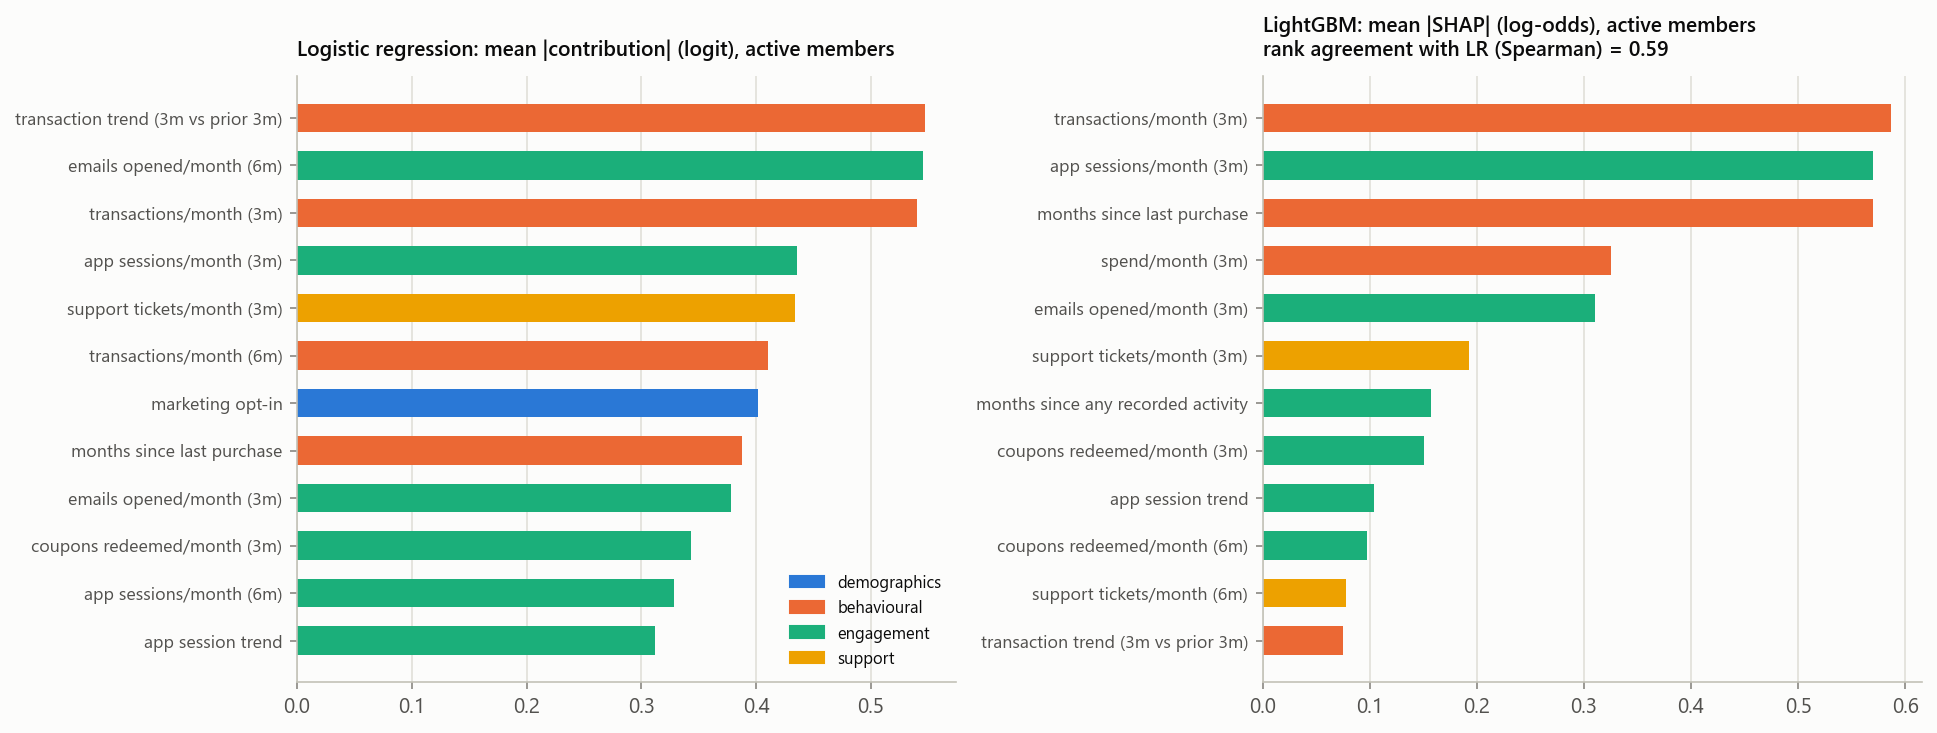

,group,all eligible,active
0,behavioural,0.451,0.404
1,demographics,0.126,0.150
2,engagement,0.366,0.375
3,support,0.057,0.071


{'spearman_rank_correlation_active': 0.588931788931789, 'top10_overlap': 6, 'top10_common_features': ['app_avg_3m', 'coupons_avg_3m', 'email_avg_3m', 'recency_months', 'tickets_avg_3m', 'txn_avg_3m']}


In [2]:
fig("drivers", 1100)
display(tab("lr_driver_group_share").round(3))
import json; print(json.load(open(P.tables / "driver_rank_agreement.json")))

**What does this show?** Left: average absolute contribution of each feature to the logistic regression's log-odds for active members. Right: LightGBM mean absolute SHAP values on the same members.

**Why is it relevant?** The brief asks for the strongest churn drivers, and the business needs to know what to watch.

**What did we learn?** Months since the last purchase, transactions in the last 3 months and their trend, emails opened, app sessions and support tickets lead in both models.

**What does it imply?** The signals are behavioural and observable every month, so they can drive a monthly risk list.

In [3]:
c = tab("lr_coefficients"); c.head(15).round(3)

,term,coef_per_sd_or_level,odds_ratio,feature
0,num__recency_months,0.835,2.304,recency_months
1,num__txn_avg_3m,-0.721,0.486,txn_avg_3m
2,num__txn_trend,-0.682,0.505,txn_trend
3,num__email_avg_6m,-0.660,0.517,email_avg_6m
4,num__months_since_any_activity,0.602,1.826,months_since_any_activity
5,num__txn_avg_6m,-0.562,0.570,txn_avg_6m
6,num__app_avg_3m,-0.556,0.573,app_avg_3m
7,num__tickets_avg_3m,0.546,1.726,tickets_avg_3m
8,num__email_avg_3m,-0.455,0.634,email_avg_3m
9,num__app_avg_6m,-0.435,0.647,app_avg_6m


Odds ratios are per standard deviation (numeric features) or vs the reference level (categories): a falling
transaction trend, fewer emails and app sessions raise risk; more support tickets raise it (OR 1.73 per sd).
**Marketing opt-in** has an odds ratio above 1 (1.51) even though opted-in members churn less in the raw data (8.5% vs
11.4%). The coefficient is conditional on emails opened: an opted-in member who stops opening emails is disengaging. A
coefficient describes an association inside the model, not the effect of changing the variable.

## 2. Local explanation: why did the model score these members the way it did?

In [4]:
le = tab("local_explanations")
for case, g in le.groupby("case", sort=False):
    r = g.iloc[0]
    display(Markdown(f"**{case}** - member {r.customer_id}: predicted {r.churn_probability:.1%}, actually churned: {bool(r.actual_churned)}"))
    display(g[["feature_name", "value", "contribution_logit"]])

**highest-risk active member** - member 502373: predicted 99.8%, actually churned: True

,feature_name,value,contribution_logit
0,support tickets/month (3m),1.33,2.752
1,transaction trend (3m vs prior 3m),-6.33,2.329
2,transactions/month (3m),1.00,0.681
3,app session trend,-2.00,0.649
4,marketing opt-in,0.00,-0.513


**active member closest to the decision threshold** - member 500627: predicted 38.1%, actually churned: False

,feature_name,value,contribution_logit
5,transactions/month (3m),1.00,0.681
6,transactions/month (6m),0.83,0.650
7,emails opened/month (6m),0.17,0.629
8,app sessions/month (3m),0.33,0.528
9,marketing opt-in,0.00,-0.513


**lowest-risk active member** - member 500026: predicted 0.0%, actually churned: False

,feature_name,value,contribution_logit
10,emails opened/month (6m),6.0,-4.541
11,emails opened/month (3m),6.0,-2.786
12,months of history,1.0,-1.223
13,coupons redeemed/month (3m),1.0,-0.472
14,months since last purchase,0.0,-0.425


**lapsed member (no purchase in the last 3 months)** - member 500045: predicted 100.0%, actually churned: True

,feature_name,value,contribution_logit
15,months since last purchase,6.0,2.224
16,months since any recorded activity,6.0,1.833
17,transactions/month (3m),0.0,0.959
18,transactions/month (6m),0.0,0.845
19,emails opened/month (6m),0.0,0.776


Each contribution is in log-odds relative to an average member: positive pushes towards churn. The prediction file
lists the three largest risk-raising contributions for every member (`key_drivers`), so a retention agent sees *why*
someone is on the list, e.g. "support tickets/month (3m) = 1.3; transaction trend = -6.3".

## 3. Risk across tier, signup cohort and city

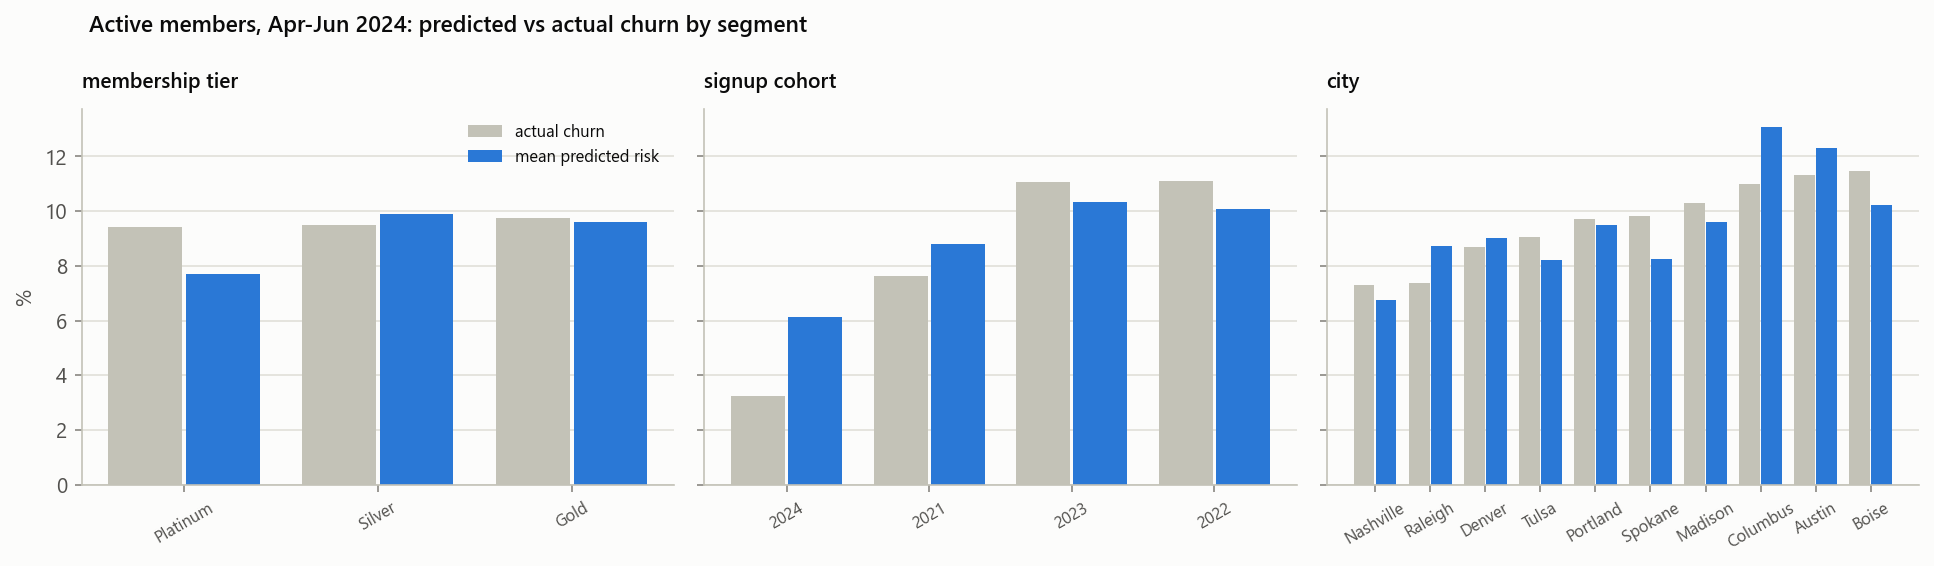

,dimension,segment,members,actual_rate,mean_predicted,share_high_risk
0,membership_tier,Gold,554,0.097,0.096,0.094
1,membership_tier,Platinum,202,0.094,0.077,0.054
2,membership_tier,Silver,959,0.095,0.099,0.092
3,city,Austin,159,0.113,0.123,0.132
4,city,Boise,166,0.114,0.102,0.102
5,city,Columbus,164,0.110,0.131,0.116
6,city,Denver,173,0.087,0.090,0.081
7,city,Madison,175,0.103,0.096,0.086
8,city,Nashville,151,0.073,0.068,0.060
9,city,Portland,165,0.097,0.095,0.085


In [5]:
fig("risk_by_segment", 1100)
tab("risk_by_segment_active").round(3)

**What does this show?** Actual churn vs mean predicted risk by segment, active members, test quarter.

**Why is it relevant?** The brief asks to compare risk across tiers, cities and signup cohorts.

**What did we learn?** Predicted and actual churn match closely by tier and city. The model over-predicts the small 2024 cohort (actual 3.2%, predicted 6.1%, 124 members).

**What does it imply?** The model is not biased towards any tier; segment differences are small compared with behavioural ones.

## 4. Ablation: do behaviour, engagement and support add value over demographics?

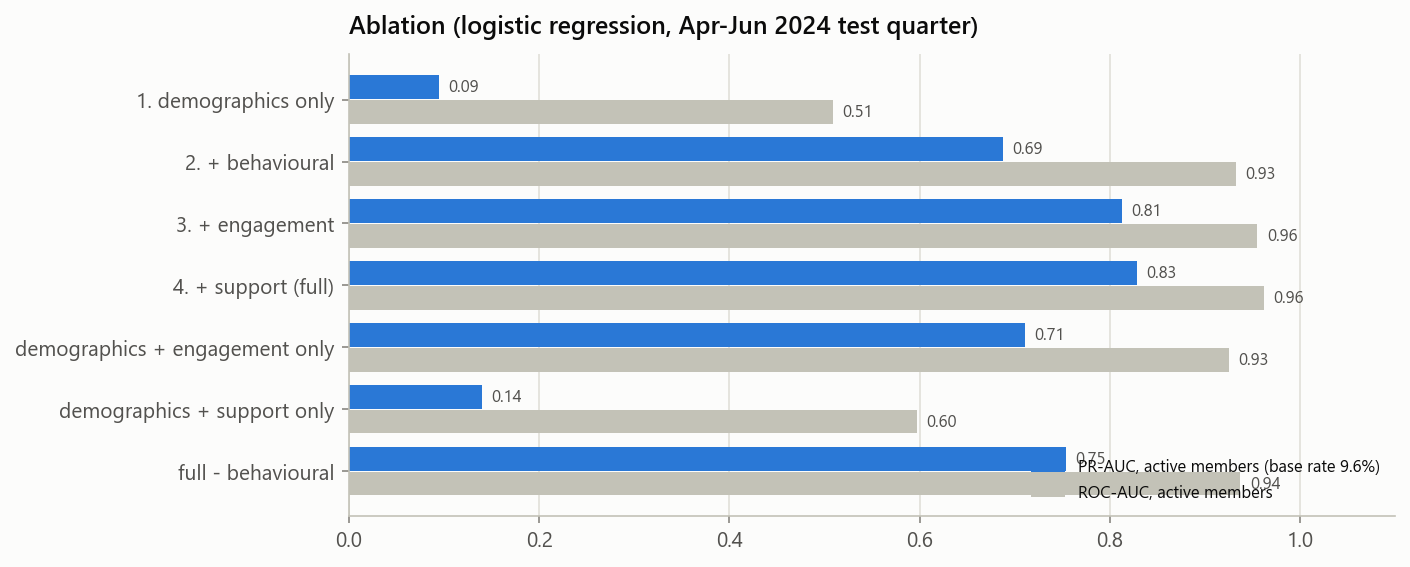

,variant,model,n_features,ROC-AUC all,PR-AUC all,ROC-AUC active,PR-AUC active
0,1. demographics only,logistic regression,8,0.615,0.429,0.508,0.095
1,1. demographics only,LightGBM,8,0.775,0.671,0.533,0.101
2,2. + behavioural,logistic regression,22,0.986,0.980,0.932,0.687
3,2. + behavioural,LightGBM,22,0.985,0.980,0.928,0.704
4,3. + engagement,logistic regression,32,0.991,0.987,0.955,0.812
5,3. + engagement,LightGBM,32,0.990,0.987,0.954,0.799
6,4. + support (full),logistic regression,36,0.992,0.989,0.962,0.828
7,4. + support (full),LightGBM,36,0.992,0.988,0.960,0.823
8,demographics + engagement only,logistic regression,18,0.984,0.979,0.925,0.711
9,demographics + engagement only,LightGBM,18,0.984,0.978,0.922,0.707


In [6]:
fig("ablation", 800)
tab("ablation").round(3)

**What does this show?** Test-quarter ROC-AUC and PR-AUC as feature groups are added (logistic regression; LightGBM in the table).

**Why is it relevant?** The brief asks whether engagement, support and behavioural features improve accuracy over demographics alone.

**What did we learn?** Demographics alone: active PR-AUC 0.095, i.e. the 9.6% base rate - no signal. + behavioural 0.687, + engagement 0.812, + support 0.828. Engagement alone (with demographics) reaches 0.711.

**What does it imply?** Collecting and refreshing behavioural and engagement data matters far more than demographic detail.